# Canadian Laws — EDA

Dataset: `a2aj/canadian-laws` (~10.9k laws & regulations, 315 MB). One row per law; paired `_en`/`_fr` columns where the missing language is empty. `unofficial_text_en/fr` is markdown-formatted full text; `unofficial_sections_en/fr` is the same content pre-segmented as JSON; `num_sections_en/fr` counts sections.

In [45]:
import torch
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import re

In [46]:
from datasets import load_dataset
ds = load_dataset("a2aj/canadian-laws")

In [47]:
train = ds["train"]
print(train)

Dataset({
    features: ['citation_en', 'citation2_en', 'dataset', 'name_en', 'document_date_en', 'source_url_en', 'scraped_timestamp_en', 'unofficial_text_en', 'unofficial_sections_en', 'num_sections_en', 'citation_fr', 'citation2_fr', 'name_fr', 'document_date_fr', 'source_url_fr', 'scraped_timestamp_fr', 'unofficial_text_fr', 'unofficial_sections_fr', 'num_sections_fr', 'upstream_license'],
    num_rows: 21610
})


In [48]:
print(f"{'Column':<30} {'Non-null':>12} | {'Null':>12} | {'Total':>12} | {'Coverage':>9}")
print("-" * 85)

for col in train.features:
    # missing values in this dataset can be None OR empty string "" — count both as null
    nonnull = sum(x is not None and x != "" for x in train[col])
    null = len(train) - nonnull

    print(
        f"{col:<30} "
        f"{nonnull:>12,} | "
        f"{null:>12,} | "
        f"{len(train):>12,} | "
        f"{nonnull / len(train) * 100:>8.2f}%"
    )

Column                             Non-null |         Null |        Total |  Coverage
-------------------------------------------------------------------------------------
citation_en                          21,600 |           10 |       21,610 |    99.95%
citation2_en                            962 |       20,648 |       21,610 |     4.45%
dataset                              21,610 |            0 |       21,610 |   100.00%
name_en                              21,610 |            0 |       21,610 |   100.00%
document_date_en                     21,577 |           33 |       21,610 |    99.85%
source_url_en                        21,610 |            0 |       21,610 |   100.00%
scraped_timestamp_en                 21,610 |            0 |       21,610 |   100.00%
unofficial_text_en                   21,610 |            0 |       21,610 |   100.00%
unofficial_sections_en               21,602 |            8 |       21,610 |    99.96%
num_sections_en                      21,610 |         

In [49]:
# drop the heavy text/sections columns before pandas (num_sections_en/fr are small ints — keep those)
drop = ["unofficial_text_en", "unofficial_text_fr",
        "unofficial_sections_en", "unofficial_sections_fr"]
df = train.remove_columns(drop).to_pandas() # converts metadata to pandas

# IMPORTANT: this dataset marks missing values as empty strings "" OR NaN.
# .notna()/.isna() only catch NaN, so normalize "" -> NA first.
df = df.replace("", pd.NA)

print(df.columns.tolist())   # confirm the exact column names
print("Number of columns = ", len(df.columns.tolist()))
df.head()

['citation_en', 'citation2_en', 'dataset', 'name_en', 'document_date_en', 'source_url_en', 'scraped_timestamp_en', 'num_sections_en', 'citation_fr', 'citation2_fr', 'name_fr', 'document_date_fr', 'source_url_fr', 'scraped_timestamp_fr', 'num_sections_fr', 'upstream_license']
Number of columns =  16


,citation_en,citation2_en,dataset,name_en,document_date_en,source_url_en,scraped_timestamp_en,num_sections_en,citation_fr,citation2_fr,name_fr,document_date_fr,source_url_fr,scraped_timestamp_fr,num_sections_fr,upstream_license
0,"RSA 2000, c A-1",NaN,LEGISLATION-AB,ABC Benefits Corporation Act,2006-01-17 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-11 02:16:02.698000+00:00,18,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
1,"SA 2024, c A-1.4",NaN,LEGISLATION-AB,Access to Information Act,2025-12-18 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-11 02:16:12.494000+00:00,103,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
2,"RSA 2000, c A-3",NaN,LEGISLATION-AB,Administrative Procedures and Jurisdiction Act,2023-04-01 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-11 02:17:00.118000+00:00,16,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
3,"RSA 2000, c A-4",NaN,LEGISLATION-AB,Adult Adoption Act,2022-11-16 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-11 02:17:14.411000+00:00,13,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...
4,"SA 2008, c A-4.2",NaN,LEGISLATION-AB,Adult Guardianship and Trusteeship Act,2026-04-01 00:00:00+00:00,https://kings-printer.alberta.ca/1266.cfm?page...,2026-07-11 02:17:28.996000+00:00,163,NaN,NaN,NaN,NaT,NaN,NaT,0,© Alberta King's Printer. Reproduced from the ...


## Basic counts & language coverage
Missing values can be `""` **or** `NaN` in this dataset, so we normalized empty strings to `NA` above — otherwise `.notna()` silently miscounts.

In [50]:
# number of english and french laws (based on which citation is present)
has_en = df["citation_en"].notna()   # True where an English citation exists
has_fr = df["citation_fr"].notna()   # True where a French citation exists

print(f"Total laws:       {len(df):,}")
print(f"Has English:      {has_en.sum():,}")
print(f"Has French:       {has_fr.sum():,}")
print(f"English only:     {(has_en & ~has_fr).sum():,}")
print(f"French only:      {(~has_en & has_fr).sum():,}")
print(f"Both languages:   {(has_en & has_fr).sum():,}")
print(f"Neither (odd!):   {(~has_en & ~has_fr).sum():,}")

# unique citations & duplicates (fall back to French citation when English missing)
citation = df["citation_en"].fillna(df["citation_fr"])
print(f"\nUnique citations:    {citation.nunique():,}")
print(f"Duplicate citations: {citation.dropna().duplicated().sum():,}")

# laws per subset, and bilingual coverage per subset
# (federal laws are legally bilingual -> expect ~100% 'Both'; BC/ON mostly English-only)
print("\nLaws per subset:")
print(df["dataset"].value_counts())
print("\nBilingual coverage by subset:")
print(pd.crosstab(df["dataset"], (has_en & has_fr).rename("both_languages")))

Total laws:       21,610
Has English:      21,600
Has French:       13,282
English only:     8,318
French only:      0
Both languages:   13,282
Neither (odd!):   10

Unique citations:    21,555
Duplicate citations: 45

Laws per subset:
dataset
REGULATIONS-FED    4868
REGULATIONS-ON     2205
REGULATIONS-NL     1663
REGULATIONS-NS     1501
REGULATIONS-BC     1466
REGULATIONS-YT     1355
REGULATIONS-MB     1093
LEGISLATION-FED     962
REGULATIONS-AB      909
LEGISLATION-ON      856
REGULATIONS-NB      675
LEGISLATION-NS      625
LEGISLATION-BC      574
REGULATIONS-NT      561
LEGISLATION-MB      515
LEGISLATION-AB      442
LEGISLATION-NB      421
LEGISLATION-NL      402
LEGISLATION-YT      278
LEGISLATION-NT      239
Name: count, dtype: int64

Bilingual coverage by subset:
both_languages   False  True 
dataset                      
LEGISLATION-AB     441      1
LEGISLATION-BC     574      0
LEGISLATION-FED      0    962
LEGISLATION-MB       0    515
LEGISLATION-NB       0    421
LEGISLATI

In [51]:
# distribution of number of characters
texts = train["unofficial_text_en"]   # list of 10,894 strings/None (fine at ~150 MB for this dataset)

# use df.index -> position in `texts`, so this keeps working after we drop rows from df
df["n_chars_en"] = [len(texts[i]) if texts[i] else 0 for i in df.index]

## Inspect the shortest documents (before cleaning)
Look before you delete. The short tail is where placeholder documents live — BC's `[Not included.]` spent amending acts, `[Repealed ...]` stubs, and possibly other sentinels. Survey them first, then decide the filter.

In [52]:
# raw output of the shortest documents, sorted by length ascending
short = df[df["n_chars_en"] > 0].sort_values("n_chars_en")

for i in short.index[7000:7500]:                     # 15 shortest — raise as needed
    t = texts[int(i)]
    print(f"{'='*80}")
    print(f"row {int(i)} | {df.loc[i,'dataset']} | {df.loc[i,'name_en']} | {len(t)} chars")
    print(f"{'='*80}")
    print(repr(t))                              # raw string: \n visible, nothing stripped
    print()

row 15150 | REGULATIONS-NL | Order - Town of Wabana Order | 2138 chars
"# Order - Town of Wabana Order\n\nCNLR 492/96\n\n### Short title\n\n1 This Order may be cited as the Town of Wabana Order.\n\n### Boundaries\n\n2 The boundaries of the Town of Wabana are as set out in the Schedule.\n\n### Repeal\n\n3 Newfoundland Regulation 854/78 is repealed.\n\n## Schedule\n\nBeginning at a point at highwater mark in the south shoreline of Freshwater Cove, that point being located at the mouth of Main Brook where the east bank of Main Brook intersects the south shoreline of Freshwater Cove at highwater mark;\nThen running in a generally easterly direction along the sinuosities of the north shoreline of Bell Island via Redman's Head to the most easterly point of Eastern Head;\nThen running in a generally southerly direction along the sinuosities of the east shoreline of Bell Island via Poll's Head, Long Harry Point and Pulpit Head to the most southerly point of the Beach;\nThen running in a genera

In [53]:
# what sentinel phrases appear in the short docs? (helps choose filter terms)
from collections import Counter
sentinels = Counter()
for i in short.index:
    t = (texts[int(i)] or "").lower()
    for phrase in ["not included", "[repealed", "repealed", "spent", "not in force", "[omitted"]:
        if phrase in t:
            sentinels[phrase] += 1
print(sentinels)


Counter({'repealed': 8336, '[repealed': 3114, 'spent': 758, 'not included': 693, 'not in force': 267, '[omitted': 1})


## Data cleaning: placeholder "stub" documents
Based on the inspection above, we remove documents that are just a title + a sentinel (`[Not included.]`, `[Repealed ...]`, ...). These are real laws legally, but their text isn't in the dataset, so they'd distort every length distribution.

**Note:** after dropping rows, `df`'s index keeps its original labels (with gaps). Do **not** `reset_index(drop=True)` — the labels are our link back to `train[i]` for fetching text.

In [54]:
# flag placeholder docs: short texts whose body is a sentinel like "[Not included.]" or "[Repealed ...]"
# (adjust the phrase list / length threshold based on what the inspection above showed)
SENTINELS = ["[not included", "[repealed"]

df["is_stub"] = [
    bool(texts[int(i)])
    and len(texts[int(i)]) < 500
    and any(s in texts[int(i)].lower() for s in SENTINELS)
    for i in df.index
]

removed = df[df["is_stub"]].copy()

print("Stub documents found:", df["is_stub"].sum())
print(df.loc[df["is_stub"], "dataset"].value_counts())
df.loc[df["is_stub"], ["dataset", "citation_en", "name_en", "n_chars_en"]].head(10)

Stub documents found: 598
dataset
REGULATIONS-FED    573
LEGISLATION-FED     19
LEGISLATION-BC       5
REGULATIONS-MB       1
Name: count, dtype: int64


,dataset,citation_en,name_en,n_chars_en
481,LEGISLATION-BC,"SBC 1996, c 9","Budget Measures Implementation Act, 1996",74
482,LEGISLATION-BC,"SBC 2000, c 22","Budget Measures Implementation Act, 2000",75
500,LEGISLATION-BC,"SBC 2018, c 17","Civil Resolution Tribunal Amendment Act, 2018",80
561,LEGISLATION-BC,"SBC 2008, c 44",Economic Incentive and Stabilization Statutes ...,100
590,LEGISLATION-BC,"SBC 2008, c 61","Expropriation Amendment Act, 2004",68
1103,LEGISLATION-FED,"RSC 1985, c 20 (4th Supp)",Canada Agricultural Products Act,391
1129,LEGISLATION-FED,"SC 2017, c 8",Canada–Ukraine Free Trade Agreement Implementa...,204
1152,LEGISLATION-FED,"SC 2012, c 19, s 52","Canadian Environmental Assessment Act, 2012",261
1236,LEGISLATION-FED,"SC 2024, c 17, s 198",Consumer-Driven Banking Act,170
1317,LEGISLATION-FED,"SC 2024, c 15, s 96",Digital Services Tax Act,151


In [ ]:
# remove the stubs (keep original index labels — no reset_index!)
print("Before:", len(df))
df = df[~df["is_stub"]]
print("After: ", len(df))

# re-check: what's the short tail like now? should be real (just brief) laws
leftover = df[df["n_chars_en"].between(1, 255)]
print(leftover[["dataset", "name_en", "n_chars_en"]].sort_values("n_chars_en").head(10))

for i in leftover.sort_values("n_chars_en").index[:120]:                     # 15 shortest — raise as needed
    t = texts[int(i)]
    print(f"{'='*80}")
    print(f"row {int(i)} | {df.loc[i,'dataset']} | {df.loc[i,'name_en']} | {len(t)} chars")
    print(f"{'='*80}")
    print(repr(t))                              # raw string: \n visible, nothing stripped
    print()

removed[["dataset", "name_en", "n_chars_en"]].sort_values("n_chars_en", ascending=False).head(10)
for i in removed.sample(3, random_state=42).index:
    print(texts[int(i)][:800], "\n" + "-"*80)

Before: 21012
After:  21012
               dataset                                            name_en  \
947     LEGISLATION-BC  South Coast British Columbia Transportation Au...   
15296   REGULATIONS-NL                    Hampden Municipal Planning Area   
19548   REGULATIONS-ON                               PRESCRIBED EMPLOYERS   
19590   REGULATIONS-ON                             PRESCRIBED INSTRUMENTS   
555     LEGISLATION-BC                                    Douglas Day Act   
18104   REGULATIONS-ON                                  FRIVOLOUS APPEALS   
19557   REGULATIONS-ON       CONTINUATION AFTER EXPIRY OF VALIDITY PERIOD   
19580   REGULATIONS-ON      PRESCRIBED PROCEDURES — SECTION 22 OF THE ACT   
19891   REGULATIONS-ON                                    TIME LIMITATION   
11201  REGULATIONS-FED                       General Import Permit No. 19   

       n_chars_en  
947            91  
15296          97  
19548         116  
19590         118  
555           124  
1810

In [67]:
# optional audit: repealed sections INSIDE living laws (kept — tiny fraction of each document's text)
df["n_repealed_secs"] = [len(re.findall(r"\[Repealed", texts[i] or "")) for i in df.index]
print("Laws containing repealed sections:", (df["n_repealed_secs"] > 0).sum())
print("Total repealed-section markers:  ", df["n_repealed_secs"].sum())

Laws containing repealed sections: 2297
Total repealed-section markers:   33033


## Length distributions (after cleaning)

Number of missing-text rows =  0


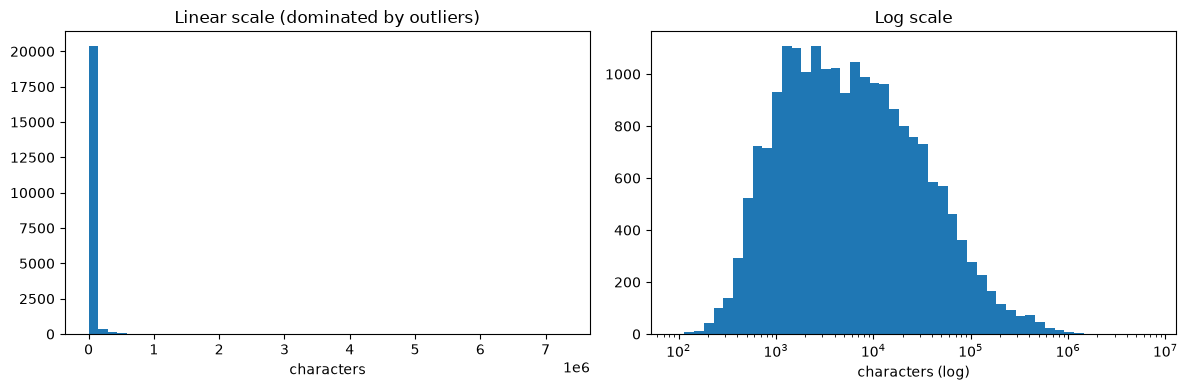

In [57]:
#plot distribution of characters
print("Number of missing-text rows = ", (df["n_chars_en"] == 0).sum())
lens = df.loc[df["n_chars_en"] > 0, "n_chars_en"]   # exclude missing-text rows

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# linear scale — see the skew
axes[0].hist(lens, bins=50)
axes[0].set_title("Linear scale (dominated by outliers)")
axes[0].set_xlabel("characters")

# log scale — see the actual shape
log_bins = np.logspace(np.log10(lens.min()), np.log10(lens.max()), 50)
axes[1].hist(lens, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_title("Log scale")
axes[1].set_xlabel("characters (log)")

plt.tight_layout()
plt.show()

In [58]:
# whitespace-delimited word counts ("s. 91(24)" counts as one word — fine for EDA, just be consistent)
df["n_words_en"] = [len(texts[i].split()) if texts[i] else 0 for i in df.index]

count    2.101200e+04
mean     4.108594e+03
std      1.473938e+04
min      1.400000e+01
25%      2.710000e+02
50%      8.955000e+02
75%      3.182500e+03
max      1.222479e+06
Name: n_words_en, dtype: float64

Shortest: South Coast British Columbia Transportation Authority Amendment Act, 2012 | # South Coast British Columbia Transportation Authority Amendment Act, 2012

SBC 2012, c 33

Longest:  Income Tax Act | # Income Tax Act

*An Act respecting income taxes*

*RSC 1985, c 1 (5th Supp)*

## Short Title

**Short Title**

**1** This Act may be cited as the Income Tax Act.

## PART I — Income Tax

### DIVISIO ...


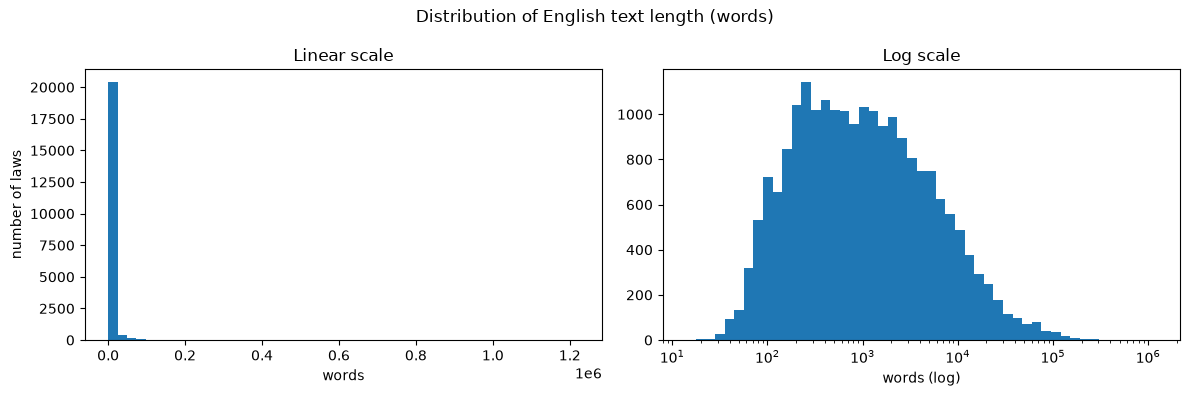

In [59]:
#plot distribution of words
words = df.loc[df["n_words_en"] > 0, "n_words_en"]
print(words.describe())

# extremes (post-cleaning) — truncated, the max is millions of chars
min_idx = df["n_words_en"].idxmin()
max_idx = df["n_words_en"].idxmax()
print("\nShortest:", df.loc[min_idx, "name_en"], "|", (texts[int(min_idx)] or "")[:200])
print("\nLongest: ", df.loc[max_idx, "name_en"], "|", texts[int(max_idx)][:200], "...")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: linear scale
axes[0].hist(words, bins=50)
axes[0].set_title("Linear scale")
axes[0].set_xlabel("words")
axes[0].set_ylabel("number of laws")

# right: log scale
log_bins = np.logspace(np.log10(words.min()), np.log10(words.max()), 50)
axes[1].hist(words, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_title("Log scale")
axes[1].set_xlabel("words (log)")

plt.suptitle("Distribution of English text length (words)")
plt.tight_layout()
plt.show()

## Sentence counts — use with caution
Sentence tokenizers assume prose, but statutes aren't prose: definitions end in **semicolons**, headers have no punctuation, clauses end in commas. Result:
- a period regex **overcounts** (splits inside citations like `R.S.C., 1985, c. B-3`)
- NLTK punkt **undercounts** (an entire definitions section with no periods = one mega-"sentence" — verified below on row 299)

So treat `n_sents_en` as approximate. **Characters, words, and `num_sections_en` are the reliable length metrics for this corpus.**

In [60]:
# pip install nltk — punkt recognizes abbreviations, so it splits sentences better than a period regex
import nltk
nltk.download("punkt_tab")   # one-time download of the sentence model
from nltk.tokenize import sent_tokenize

# NOTE: slow (~minutes) — tokenizes every English text
df["n_sents_en"] = [len(sent_tokenize(texts[i])) if texts[i] else 0 for i in df.index]

[nltk_data] Downloading package punkt_tab to /Users/amyxu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [61]:
text = train[299]["unofficial_text_en"]
sentences = sent_tokenize(text or "")
print("Sentence count:", len(sentences))          # should match df.loc[299, 'n_sents_en'] if you used NLTK
print("Sample sentence:", sentences[0])

Sentence count: 93
Sample sentence: # Personal Directives Act

RSA 2000, c P-6

### Preamble

WHEREAS Albertans should be able to provide advance personal instructions regarding their own personal matters while recognizing that such instructions may only be made voluntarily and cannot include instructions relating to aided suicide, euthanasia or other instructions prohibited by law;
THEREFORE HER MAJESTY, by and with the advice and consent of the Legislative Assembly of Alberta, enacts as follows:

## Part 1 Definitions and Application

### Definitions

1 In this Act,
(a) “agent” means a person designated in a personal directive to make personal decisions on behalf of the maker;
(b) “capacity” means the ability to understand the information that is relevant to the making of a personal decision and the ability to appreciate the reasonably foreseeable consequences of the decision;
(b.1) “complaint” means a complaint made under section 24.2;
(c) “Court” means the Court of King’s Bench;
(d

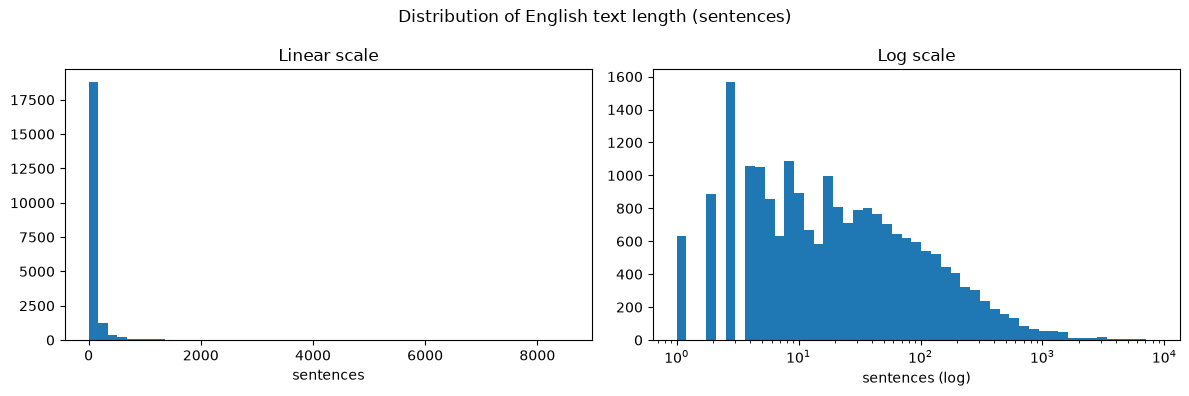

In [62]:
sents = df.loc[df["n_sents_en"] > 0, "n_sents_en"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sents, bins=50)
axes[0].set_title("Linear scale")
axes[0].set_xlabel("sentences")
log_bins = np.logspace(np.log10(sents.min()), np.log10(sents.max()), 50)
axes[1].hist(sents, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_title("Log scale")
axes[1].set_xlabel("sentences (log)")
plt.suptitle("Distribution of English text length (sentences)")
plt.tight_layout()
plt.show()

## Paragraphs (markdown blocks, headers excluded)
Better-defined than sentences for statutory text.

In [63]:
# "paragraphs" = markdown blocks separated by blank lines, EXCLUDING header lines (#, ##, ###)
def count_blocks(text):
    if not text:
        return 0
    blocks = [p.strip() for p in text.split("\n\n") if p.strip()]
    return sum(1 for p in blocks if not p.startswith("#"))

df["n_paras_en"] = [count_blocks(texts[i]) for i in df.index]

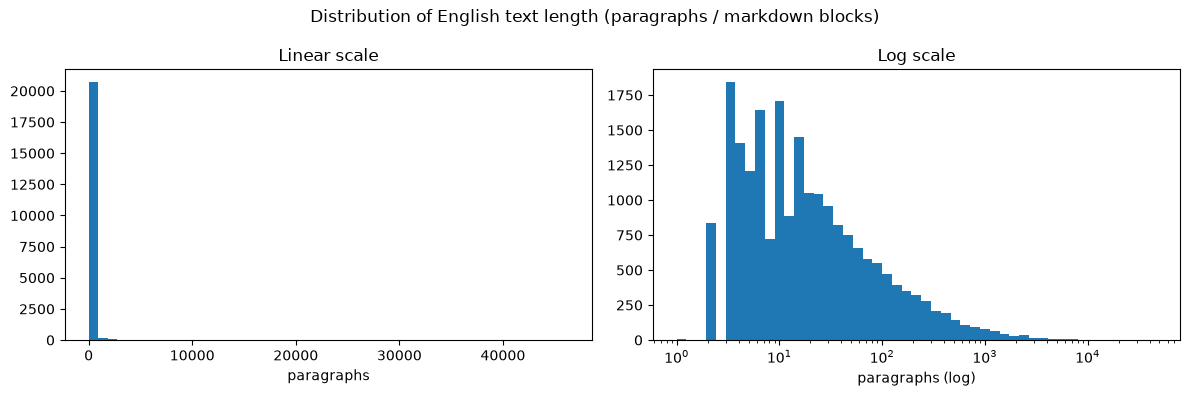

In [64]:
paras = df.loc[df["n_paras_en"] > 0, "n_paras_en"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(paras, bins=50)
axes[0].set_title("Linear scale")
axes[0].set_xlabel("paragraphs")
log_bins = np.logspace(np.log10(paras.min()), np.log10(paras.max()), 50)
axes[1].hist(paras, bins=log_bins)
axes[1].set_xscale("log")
axes[1].set_title("Log scale")
axes[1].set_xlabel("paragraphs (log)")
plt.suptitle("Distribution of English text length (paragraphs / markdown blocks)")
plt.tight_layout()
plt.show()

## Sections — the natural unit of legal documents
The maintainers already segmented every law; `num_sections_en` is more meaningful than sentences here.

count    21012.000000
mean        25.323101
std         94.189222
min          0.000000
25%          3.000000
50%          8.000000
75%         22.000000
max       9762.000000
Name: num_sections_en, dtype: float64
            citation_en                                    name_en  \
8228         CRC, c 945                     Income Tax Regulations   
1540      SC 2010, c 12               Jobs and Economic Growth Act   
7684      BC Reg 296/97  Occupational Health and Safety Regulation   
8203         CRC, c 870                  Food and Drug Regulations   
1257   RSC 1985, c C-46                              Criminal Code   
12276        SOR/96-433              Canadian Aviation Regulations   
18398      O Reg 213/07                                  fire code   
1052      SC 1991, c 46                                   Bank Act   
1488      SC 1991, c 47                    Insurance Companies Act   
10284       SOR/2010-91                   Small Vessel Regulations   

               

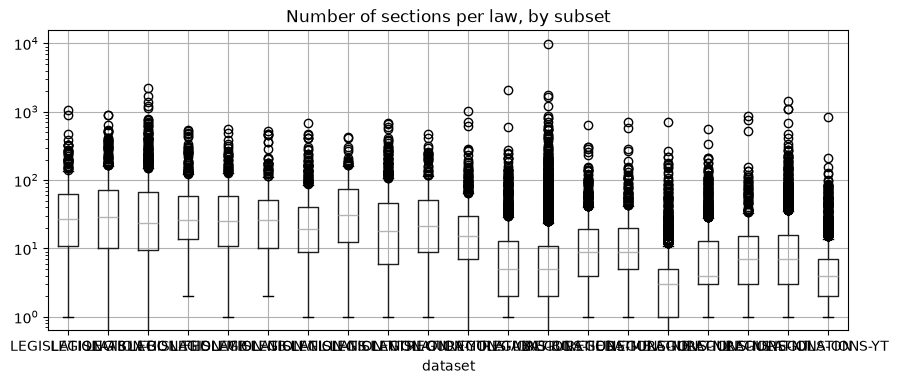

In [65]:
print(df["num_sections_en"].describe())

# biggest laws by section count
print(df.nlargest(10, "num_sections_en")[["citation_en", "name_en", "dataset", "num_sections_en"]])

# section counts by subset (log scale — heavy-tailed like everything else)
df.boxplot(column="num_sections_en", by="dataset", figsize=(10, 4))
plt.yscale("log")
plt.suptitle("")
plt.title("Number of sections per law, by subset")
plt.show()

## Markdown structure check
Texts come from three different official sources (federal Justice Laws, ON e-Laws, BCLaws), each converted to markdown — general conventions match (`#` headers, blank-line blocks) but details can vary by subset. Below: header/body breakdown for one document.

In [66]:
blocks = [p.strip() for p in text.split("\n\n") if p.strip()]
headers = [p for p in blocks if p.startswith("#")]
body    = [p for p in blocks if not p.startswith("#")]
print(f"{len(blocks)} blocks = {len(headers)} headers + {len(body)} body blocks")
print("Mid 3 body blocks:", body[197:200])

102 blocks = 55 headers + 47 body blocks
Mid 3 body blocks: []
